# Célula 1 — Imports

In [197]:
from pathlib import Path
import random
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
 
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
 
import yfinance as yf
import requests
from arch import arch_model
from scipy.stats import spearmanr

In [198]:
def qlike(y_true, y_pred):
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

def eval_metrics(y_true, y_pred, label):
    print(f"\n── {label} ──")
    print(f"  QLIKE    : {qlike(y_true, y_pred):.6f}  (baseline média: {qlike(y_true, np.full_like(y_true, y_true.mean())):.6f})")
    print(f"  R²       : {r2_score(y_true, y_pred):.4f}")
    print(f"  Spearman : {spearmanr(y_true, y_pred).statistic:.4f}")
    print(f"  std ratio: {y_pred.std() / y_true.std():.3f}  (ideal=1.0)")

# Célula 2 — Constantes 

In [199]:
START          = "2008-01-01"
END            = "2025-04-14"
TEST_RATIO     = 0.1
SEED           = 42
WINDOW_SIZE    = 60       
VOL_WINDOW     = 10    # era 21
VOL_SHIFT      = -5   # era -21
 
FRED_API_KEY   = "a75bdc9f7da239a5e3d6c8e389345bfb"
DATA_BASE_PATH = Path("./data")
 
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Célula 3 - Requição para API do FRED

In [200]:
def get_fred_series(series_id: str, start: str, end: str, api_key: str) -> pd.DataFrame:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["timestamp", series_id.lower()]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df[series_id.lower()] = pd.to_numeric(df[series_id.lower()], errors="coerce")
    return df.reset_index(drop=True)
 
dfii10 = get_fred_series("DFII10", START, END, FRED_API_KEY)
dfii10 = dfii10.rename(columns={"dfii10": "inflation"})
print(dfii10.shape)
print(dfii10.head())

(4510, 2)
   timestamp  inflation
0 2008-01-01        NaN
1 2008-01-02       1.59
2 2008-01-03       1.58
3 2008-01-04       1.56
4 2008-01-07       1.57


# Células 4, 5, 6 e 7 - Carrega dataframes

In [201]:
petrodolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_5_daily_prices_fx.csv",
    parse_dates=["date"]
)
petrodolar = petrodolar.rename(columns={"date": "timestamp"})
petrodolar = petrodolar[[
    "timestamp",
    "brent_crude_usd",
    "wti_crude_usd",
    "brent_wti_spread",
    "usd_dxy_index",
    "eur_usd",
    "usd_rub",
]]
petrodolar = petrodolar[
    (petrodolar["timestamp"] >= START) &
    (petrodolar["timestamp"] <= END)
].reset_index(drop=True)

print(petrodolar.shape)
print(petrodolar.head())

(4510, 7)
   timestamp  brent_crude_usd  wti_crude_usd  brent_wti_spread  usd_dxy_index  \
0 2008-01-01            95.43          89.45              5.98          81.79   
1 2008-01-02            95.20          90.40              4.80          80.31   
2 2008-01-03            93.60          90.02              3.58          81.91   
3 2008-01-04            94.70          92.72              1.98          81.00   
4 2008-01-07            94.69          89.33              5.36          80.54   

   eur_usd  usd_rub  
0   1.2725    30.51  
1   1.2891    30.16  
2   1.2693    29.76  
3   1.2834    29.98  
4   1.2971    30.36  


In [202]:
opec = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_2_opec_quotas_events.csv",
    parse_dates=["date"]
)
opec = opec.rename(columns={"date": "timestamp"})
opec["timestamp"] = pd.to_datetime(opec["timestamp"])
opec = opec[[
    "timestamp",
    "opec_compliance_pct",
    "oil_market_balance_mbd",
    "us_shale_production_mbd",
]].copy()

# Dataset 4 — Dedolarização
dedolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_4_dedollarization.csv",
    parse_dates=["date"]
)
dedolar = dedolar.rename(columns={"date": "timestamp"})
dedolar["timestamp"] = pd.to_datetime(dedolar["timestamp"])
dedolar = dedolar[[
    "timestamp",
    "de_dollarization_pressure_index",
    "brics_gold_reserves_tonnes",
    "usd_global_fx_reserves_pct",
]].copy()

# Dataset 3 — SWF (anual)
swf = pd.read_csv(DATA_BASE_PATH / "petrodollar_3_recycling_swf.csv")
swf = swf[["year", "global_fx_reserves_gold_share_pct"]].copy()

print("OPEC:", opec.shape)
print("Dedolar:", dedolar.shape)
print("SWF:", swf.shape)

OPEC: (312, 4)
Dedolar: (252, 4)
SWF: (26, 2)


In [203]:
tickers = {
    "dxy":   "DX-Y.NYB",
    "vix":   "^VIX",
    "oil":   "CL=F",
    "tips":  "TIP",
    "sp500": "^GSPC",
    "tnx": "^TNX",
    "gvz":   "^GVZ",
}

dfs = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = name
    dfs[name] = close

externos = pd.concat(dfs.values(), axis=1)
externos.index.name = "timestamp"
externos = externos.reset_index()

print(externos.shape)
print(externos.head())

(4350, 8)
   timestamp        dxy        vix        oil       tips        sp500    tnx  \
0 2008-01-02  75.970001  23.170000  99.620003  62.980518  1447.160034  3.901   
1 2008-01-03  75.889999  22.490000  99.180000  63.193130  1447.160034  3.901   
2 2008-01-04  75.790001  23.940001  97.910004  63.175446  1411.630005  3.854   
3 2008-01-07  76.169998  23.790001  95.089996  63.163597  1416.180054  3.839   
4 2008-01-08  76.110001  25.430000  96.330002  63.210838  1390.189941  3.840   

   gvz  
0  NaN  
1  NaN  
2  NaN  
3  NaN  
4  NaN  


In [204]:
gold      = pd.read_csv(DATA_BASE_PATH / "final_gold_data.csv",      sep=";", encoding="utf-8", parse_dates=["timestamp"])
palladium = pd.read_csv(DATA_BASE_PATH / "final_palladium_data.csv", sep=";", encoding="utf-8", parse_dates=["timestamp"])
platinum  = pd.read_csv(DATA_BASE_PATH / "final_platinum_data.csv",  sep=";", encoding="utf-8", parse_dates=["timestamp"])
silver    = pd.read_csv(DATA_BASE_PATH / "final_silver_data.csv",    sep=";", encoding="utf-8", parse_dates=["timestamp"])

cols_to_drop = ["currency", "unit", "headlines"]
for name, df in [("palladium", palladium), ("platinum", platinum), ("silver", silver)]:
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    df.rename(columns={
        "open":   f"{name}_open",
        "high":   f"{name}_high",
        "low":    f"{name}_low",
        "close":  f"{name}_close",
        "volume": f"{name}_volume",
    }, inplace=True)

print("Gold:", gold.shape)

Gold: (6177, 9)


# Célula 8 - Merges

In [205]:
for df in [gold, palladium, platinum, silver, externos]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

gold = gold.merge(palladium,  on="timestamp", how="left")
gold = gold.merge(platinum,   on="timestamp", how="left")
gold = gold.merge(silver,     on="timestamp", how="left")
gold = gold.merge(externos,   on="timestamp", how="left")
gold = gold.merge(dfii10,     on="timestamp", how="left")
gold = gold.merge(petrodolar, on="timestamp", how="left")

# Merge mensal: OPEC e dedolarização (merge por ano+mês)
gold["year"]  = gold["timestamp"].dt.year
gold["month_"] = gold["timestamp"].dt.month

opec["year"]   = opec["timestamp"].dt.year
opec["month_"] = opec["timestamp"].dt.month
opec = opec.drop(columns=["timestamp"])

dedolar["year"]   = dedolar["timestamp"].dt.year
dedolar["month_"] = dedolar["timestamp"].dt.month
dedolar = dedolar.drop(columns=["timestamp"])

gold = gold.merge(opec,    on=["year", "month_"], how="left")
gold = gold.merge(dedolar, on=["year", "month_"], how="left")
gold = gold.merge(swf,     on="year",             how="left")
gold = gold.drop(columns=["year", "month_"])

fill_cols = [
    "dxy", "vix", "oil", "tips", "sp500", "tnx",
    "palladium_close", "palladium_open", "palladium_high", "palladium_low",
    "platinum_close",  "platinum_open",  "platinum_high",  "platinum_low",
    "silver_close",    "silver_open",    "silver_high",    "silver_low",
    "inflation",
    "brent_crude_usd", "wti_crude_usd", "brent_wti_spread", "usd_dxy_index", "eur_usd", "usd_rub",
    "opec_compliance_pct", "oil_market_balance_mbd", "us_shale_production_mbd",
    "de_dollarization_pressure_index", "brics_gold_reserves_tonnes", "usd_global_fx_reserves_pct",
    "global_fx_reserves_gold_share_pct",
]

gold[fill_cols] = gold[fill_cols].ffill().bfill()
gold = gold.dropna()

print("Shape após merge:", gold.shape)
print(gold.isna().sum()[gold.isna().sum() > 0])

Shape após merge: (3939, 45)
Series([], dtype: int64)


# Célula 9 - Feature Engineering

In [206]:
gold["day_variation"]  = gold["open"] - gold["close"]
gold["tomorrow_close"] = gold["close"].shift(-1)
gold = gold.dropna(subset=["tomorrow_close"])
 
gold["target_return"] = (gold["tomorrow_close"] - gold["close"]) / gold["close"]
gold["month"]         = gold["timestamp"].dt.month
 
gold["sma_5"]     = gold["close"].rolling(5).mean()
gold["sma_20"]    = gold["close"].rolling(20).mean()
gold["sma_ratio"] = gold["sma_5"] / gold["sma_20"]   # <- adimensional, mantida
 
ema_12 = gold["close"].ewm(span=12).mean()
ema_26 = gold["close"].ewm(span=26).mean()
gold["macd"]        = ema_12 - ema_26
gold["macd_signal"] = gold["macd"].ewm(span=9).mean()
 
rolling_std         = gold["close"].rolling(20).std()
gold["bb_position"] = (gold["close"] - (gold["sma_20"] - 2*rolling_std)) / (4 * rolling_std)  # adimensional [0,1]
 
gold["roc_10"] = gold["close"].pct_change(10)
 
gold["real_rate_proxy"] = gold["tnx"] - gold["inflation"]
gold["petrodolar_brent"] = gold["brent_crude_usd"] / gold["usd_dxy_index"]
gold["brent_roc_20"]     = gold["brent_crude_usd"].pct_change(20)
gold["brent_vol_20"]     = gold["brent_crude_usd"].pct_change().rolling(20).std()
gold["close_return"] = gold["close"].pct_change()
gold["gvz_pct_change"] = gold["gvz"].pct_change(5)
gold["gvz_zscore_60d"] = (
    (gold["gvz"] - gold["gvz"].rolling(60).mean())
    / gold["gvz"].rolling(60).std()
)
 
delta    = gold["close"].diff()
gain     = delta.clip(lower=0)
loss     = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
gold["rsi_14"] = 100 - (100 / (1 + rs))
 
gold["log_return"] = np.log(gold["close"] / gold["close"].shift(1))
gold["hist_vol_5"]  = gold["log_return"].rolling(5).std()
gold["hist_vol_10"] = gold["log_return"].rolling(10).std()
gold["hist_vol_20"] = gold["log_return"].rolling(20).std()
gold["hist_vol_60"] = gold["log_return"].rolling(60).std()

gold["target_vol_5d"] = gold["log_return"].rolling(VOL_WINDOW).std().shift(VOL_SHIFT)
gold["rv_5"] = gold["log_return"].rolling(5).std()
gold["rv_20"] = gold["log_return"].rolling(20).std()
gold["rv_60"] = gold["log_return"].rolling(60).std()
gold["rv_20_rank"] = (
    gold["rv_20"]
    .rolling(252)
    .rank(pct=True)
)

gold["vix_rank"] = (
    gold["vix"]
    .rolling(252)
    .rank(pct=True)
)

log_ret = gold["log_return"].dropna() * 100
garch_full = arch_model(log_ret, vol="Garch", p=1, q=1)
res_full = garch_full.fit(disp="off")

gold_aligned = gold[gold["log_return"].notna()].copy()

gold_aligned["garch_vol"] = res_full.conditional_volatility.values / 100

gold = gold.merge(
    gold_aligned[["timestamp", "garch_vol"]],
    on="timestamp", how="left"
)

gold["garch_rank"] = (
    gold["garch_vol"]
    .rolling(252)
    .rank(pct=True)
)

def rolling_percentile(series, window=252):
    return (
        series.rolling(window)
        .rank(pct=True)
    )

gold["vix_rank_252"] = rolling_percentile(gold["vix"])
gold["garch_rank_252"] = rolling_percentile(gold["garch_vol"])
gold["rv20_rank_252"] = rolling_percentile(gold["rv_20"])
gold["dxy_rank_252"] = rolling_percentile(gold["dxy"])

gold = gold.dropna()
print("Shape após feature engineering:", gold.shape)
print("NaN restantes:", gold.isna().sum().sum())


Shape após feature engineering: (3662, 81)
NaN restantes: 0


# Célula 10 - Target

In [207]:
TARGET = "target_vol_5d"
 
to_drop = [
    "currency", "unit", "timestamp", "headlines",
    "tomorrow_close", "target_return", "log_return",
    "close"
]
 
# MELHORIA 2: removidas features em nível absoluto de preço
cols_to_remove = [
    # Nível absoluto de preço -> leakage indireto via autocorrelação do close
    "sma_5",         # substituída por sma_ratio
    "sma_20",        # substituída por sma_ratio
    "bb_upper",      # substituída por bb_position
    "bb_lower",      # substituída por bb_position
    "high", "low", "open",   # em nível — usar só close como âncora temporal
 
    # Redundâncias conhecidas
    "wti_crude_usd",
    "petrodolar_wti",
    "usd_dxy_index",   # duplicata do dxy
    "max_diff",
    "silver_low",
    "platinum_volume",
    "palladium_volume",
    "gvz",
    "gvz_vix_spread",
    "garch_vol",   # fitado em todo o dataset — leakage
    "gvz",
    "gvz_vix_spread",
]
 
X = gold.drop(columns=[c for c in to_drop + [TARGET] + cols_to_remove if c in gold.columns])
y = gold[TARGET]
 
n_features = X.shape[1]
print("Features restantes:", list(X.columns))
print("n_features:", n_features)

Features restantes: ['volume', 'palladium_open', 'palladium_high', 'palladium_low', 'palladium_close', 'platinum_open', 'platinum_high', 'platinum_low', 'platinum_close', 'silver_open', 'silver_high', 'silver_close', 'silver_volume', 'dxy', 'vix', 'oil', 'tips', 'sp500', 'tnx', 'inflation', 'brent_crude_usd', 'brent_wti_spread', 'eur_usd', 'usd_rub', 'opec_compliance_pct', 'oil_market_balance_mbd', 'us_shale_production_mbd', 'de_dollarization_pressure_index', 'brics_gold_reserves_tonnes', 'usd_global_fx_reserves_pct', 'global_fx_reserves_gold_share_pct', 'day_variation', 'month', 'sma_ratio', 'macd', 'macd_signal', 'bb_position', 'roc_10', 'real_rate_proxy', 'petrodolar_brent', 'brent_roc_20', 'brent_vol_20', 'close_return', 'gvz_pct_change', 'gvz_zscore_60d', 'rsi_14', 'hist_vol_5', 'hist_vol_10', 'hist_vol_20', 'hist_vol_60', 'rv_5', 'rv_20', 'rv_60', 'rv_20_rank', 'vix_rank', 'garch_rank', 'vix_rank_252', 'garch_rank_252', 'rv20_rank_252', 'dxy_rank_252']
n_features: 60


In [208]:
split_idx = int(len(gold) * (1 - TEST_RATIO))
 
vix_train = gold["vix"].iloc[:split_idx].values
vix_test  = gold["vix"].iloc[split_idx:].values
y_train_bl = y.iloc[:split_idx].values
y_test_bl  = y.iloc[split_idx:].values
 
# Regressão linear simples VIX -> target_vol
ridge_bl = Ridge(alpha=1.0)
ridge_bl.fit(vix_train.reshape(-1, 1), y_train_bl)
vix_pred_test = ridge_bl.predict(vix_test.reshape(-1, 1))
 
r2_vix  = r2_score(y_test_bl, vix_pred_test)
mae_vix = mean_absolute_error(y_test_bl, vix_pred_test)
print(f"\n── Baseline VIX -> vol ──")
print(f"  R²  (teste): {r2_vix:.4f}")
print(f"  MAE (teste): {mae_vix:.6f}")
print(f"  Correlação : {np.corrcoef(y_test_bl, vix_pred_test)[0,1]:.4f}")
print("  (O LSTM precisa superar esse baseline para justificar sua complexidade)")



── Baseline VIX -> vol ──
  R²  (teste): -0.2460
  MAE (teste): 0.002326
  Correlação : -0.0585
  (O LSTM precisa superar esse baseline para justificar sua complexidade)


# Célula 11 - Create sequences

In [209]:
# Célula 7 — Sequences + split
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i + window_size])
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X.to_numpy(), y, WINDOW_SIZE)

mask  = ~np.isnan(y_seq)
X_seq = X_seq[mask]
y_seq = y_seq[mask]

print("NaN em y_seq após mask:", np.isnan(y_seq).sum())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_RATIO, shuffle=False
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)

NaN em y_seq após mask: 0
Train: (3241, 60, 60) Test: (361, 60, 60)


# Célula 12 - Criação do modelo

In [210]:
from tensorflow.keras.layers import GRU

def build_model(learning_rate=0.0001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        GRU(64),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate), loss="huber")
    return model

# Célula 13 - Normalização

In [211]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(
    X_train_full.reshape(-1, n_features)
).reshape(X_train_full.shape)
X_test_scaled = x_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_full.reshape(-1, 1)).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled mean:", y_train_scaled.mean(), "std:", y_train_scaled.std())

X_train_scaled: (3241, 60, 60)
y_train_scaled mean: -3.5077703709230494e-16 std: 0.9999999999999998


# Célula 14 - Separação em treino e teste

In [212]:
tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_seq))

walk_r2s = []
last_val_idx = None  # <- salva índices, não os dados escalados

for fold, (train_idx, val_idx) in enumerate(folds):
    X_tr = X_seq[train_idx];  X_va = X_seq[val_idx]
    y_tr = y_seq[train_idx];  y_va = y_seq[val_idx]

    sc_x = StandardScaler()
    X_tr_s = sc_x.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_va_s = sc_x.transform(X_va.reshape(-1, n_features)).reshape(X_va.shape)

    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_va_s = sc_y.transform(y_va.reshape(-1, 1)).ravel()

    tf.keras.backend.clear_session()
    m = build_model()
    m.fit(
        X_tr_s, y_tr_s,
        epochs=100, batch_size=32,
        validation_data=(X_va_s, y_va_s),
        shuffle=False, verbose=0,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)]
    )

    pred_s = m.predict(X_va_s, verbose=0)
    pred   = sc_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    r2 = r2_score(y_va, pred)
    walk_r2s.append(r2)
    print(f"Fold {fold+1} R²: {r2:.4f}  |  pred_std: {pred.std():.6f}  |  real_std: {y_va.std():.6f}")

    if fold == len(folds) - 1:
        last_val_idx = val_idx  # <- só os índices

print(f"\nR² médio walk-forward: {np.mean(walk_r2s):.4f}")

# Reescalar com o scaler global 
val_X_final = x_scaler.transform(
    X_seq[last_val_idx].reshape(-1, n_features)
).reshape(X_seq[last_val_idx].shape)

val_y_final = y_scaler.transform(
    y_seq[last_val_idx].reshape(-1, 1)
).ravel()

Fold 1 R²: -6.7193  |  pred_std: 0.003143  |  real_std: 0.003843
Fold 2 R²: -0.2773  |  pred_std: 0.001086  |  real_std: 0.002978
Fold 3 R²: 0.2328  |  pred_std: 0.001692  |  real_std: 0.004867
Fold 4 R²: 0.1928  |  pred_std: 0.001733  |  real_std: 0.003349
Fold 5 R²: 0.2000  |  pred_std: 0.001579  |  real_std: 0.002766

R² médio walk-forward: -1.2742


# Célula 15 - Treino

In [213]:
TRAIN_YEARS = 4

seq_ts = gold["timestamp"].iloc[WINDOW_SIZE:].reset_index(drop=True)
seq_ts = seq_ts.iloc[mask].reset_index(drop=True)

test_start  = seq_ts.iloc[int(len(seq_ts) * (1 - TEST_RATIO))]
train_end   = test_start
train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)

slide_mask = (seq_ts >= train_start) & (seq_ts < train_end)
slide_mask = slide_mask.values

X_slide = X_seq[slide_mask]
y_slide = y_seq[slide_mask]

print(f"Janela de treino: {train_start.date()} → {train_end.date()}")
print(f"Amostras: {X_slide.shape}")

x_scaler_slide = StandardScaler()
X_slide_s = x_scaler_slide.fit_transform(
    X_slide.reshape(-1, n_features)
).reshape(X_slide.shape)

y_scaler_slide = StandardScaler()
y_slide_s = y_scaler_slide.fit_transform(y_slide.reshape(-1, 1)).ravel()

# Escala o teste com o scaler da janela deslizante
X_test_slide_s = x_scaler_slide.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

# Val set = últimos 15% da janela deslizante (dentro do treino)
val_cut = int(len(X_slide_s) * 0.85)
val_X_slide  = X_slide_s[val_cut:]
val_y_slide  = y_slide_s[val_cut:]
X_slide_train = X_slide_s[:val_cut]
y_slide_train = y_slide_s[:val_cut]

print(f"Treino: {X_slide_train.shape}  Val: {val_X_slide.shape}")

tf.keras.backend.clear_session()
final_model = build_model()

history = final_model.fit(
    X_slide_train, y_slide_train,
    validation_data=(val_X_slide, val_y_slide),
    epochs=500,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=20,
                      restore_best_weights=True, min_delta=1e-6),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=15, min_lr=1e-6, verbose=1),
    ],
    verbose=1,
)

y_pred_slide_train = y_scaler_slide.inverse_transform(
    final_model.predict(X_slide_train, verbose=0)
).flatten()

y_pred_slide_test = y_scaler_slide.inverse_transform(
    final_model.predict(X_test_slide_s, verbose=0)
).flatten()

y_test_eval = y_test

eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test_eval,       y_pred_slide_test,  "LSTM TEST  (slide)")

Janela de treino: 2019-10-25 → 2023-10-25
Amostras: (1006, 60, 60)
Treino: (855, 60, 60)  Val: (151, 60, 60)
Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - loss: 0.5856 - val_loss: 0.4242 - learning_rate: 1.0000e-04
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.5170 - val_loss: 0.3556 - learning_rate: 1.0000e-04
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.4591 - val_loss: 0.3117 - learning_rate: 1.0000e-04
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.4130 - val_loss: 0.2680 - learning_rate: 1.0000e-04
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.3684 - val_loss: 0.2443 - learning_rate: 1.0000e-04
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.3539 - val_loss: 0.2356 - learning_rate: 1.0000e-04
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.3412 - val_loss: 0.2277 - learning_rate: 1.0000e-04
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.3152 - val_loss: 0.2234 - lea

In [214]:
print("y_train_scaled mean:", y_train_scaled.mean())
print("y_train_scaled std: ", y_train_scaled.std())
print("y_train_scaled min: ", y_train_scaled.min())
print("y_train_scaled max: ", y_train_scaled.max())
print("NaN em y_train_scaled:", np.isnan(y_train_scaled).sum())
print("NaN em X_train_scaled:", np.isnan(X_train_scaled).sum())

y_train_scaled mean: -3.5077703709230494e-16
y_train_scaled std:  0.9999999999999998
y_train_scaled min:  -1.644340442444795
y_train_scaled max:  6.51891141678079
NaN em y_train_scaled: 0


NaN em X_train_scaled: 0


In [215]:
nan_cols = X.columns[X.isna().any()].tolist()
print("Colunas com NaN:", nan_cols)
print(X[nan_cols].isna().sum())

Colunas com NaN: []
Series([], dtype: float64)


# Célula 16 - Métricas

In [216]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()
y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()
 
print("Pred treino std:", y_pred_train.std())
print("Real treino std:", y_train_full.std())
print("Pred teste  std:", y_pred_test.std())
print("Real teste  std:", y_test.std())
 
for name, y_true, y_pred in [
    ("TRAIN", y_train_full, y_pred_train),
    ("TEST",  y_test,       y_pred_test),
]:
    print(f"\n{'='*60}\n{name} METRICS\n{'='*60}")
    print("MAE:  ", mean_absolute_error(y_true, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:   ", r2_score(y_true, y_pred))
    baseline = np.full_like(y_true, fill_value=y_train_full.mean())
    print("R2 baseline (média):", r2_score(y_true, baseline))
    print("R2 baseline (VIX)  :", r2_vix, "<- barra real a superar")
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print("Correlação pred vs real:", corr)

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Pred treino std: 0.0022620636
Real treino std: 0.004314333582127048
Pred teste  std: 0.0006697851
Real teste  std: 0.0026033636166382045

TRAIN METRICS
MAE:   0.0024472392950425593
RMSE:  0.003607591371563361
R2:    0.30079063565061237
R2 baseline (média): 0.0
R2 baseline (VIX)  : -0.24598932112640526 <- barra real a superar
Correlação pred vs real: 0.5538826973182807

TEST METRICS
MAE:   0.0023050596515854227
RMSE:  0.002744351118924509
R2:    -0.11124466361040408
R2 baseline (média): -0.005434124156396658
R2 baseline (VIX)  : -0.24598932112640526 <- barra real a superar
Correlação pred vs real: 0.21222896749649442


In [217]:
y_pred_train = y_scaler.inverse_transform(
    final_model.predict(X_train_scaled)
).flatten()
y_pred_test = y_scaler.inverse_transform(
    final_model.predict(X_test_scaled)
).flatten()

eval_metrics(y_train_full, y_pred_train, "LSTM TRAIN")
eval_metrics(y_test,       y_pred_test,  "LSTM TEST")

102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

── LSTM TRAIN ──
  QLIKE    : 0.066487  (baseline média: 0.088827)
  R²       : 0.3008
  Spearman : 0.5353
  std ratio: 0.524  (ideal=1.0)

── LSTM TEST ──
  QLIKE    : 0.045453  (baseline média: 0.041931)
  R²       : -0.1112
  Spearman : 0.1695
  std ratio: 0.257  (ideal=1.0)


In [218]:
seq_ts = gold["timestamp"].iloc[WINDOW_SIZE:].reset_index(drop=True)
seq_ts = seq_ts.iloc[mask]

test_start = seq_ts.iloc[int(len(seq_ts) * (1 - TEST_RATIO))]
test_end   = seq_ts.iloc[-1]

print(f"Teste: {test_start.date()} → {test_end.date()}")
print(f"Dias no teste: {len(y_test)}")
print(f"Dias no treino completo: {len(y_train_full)}")

Teste: 2023-10-25 → 2025-04-03
Dias no teste: 361
Dias no treino completo: 3241


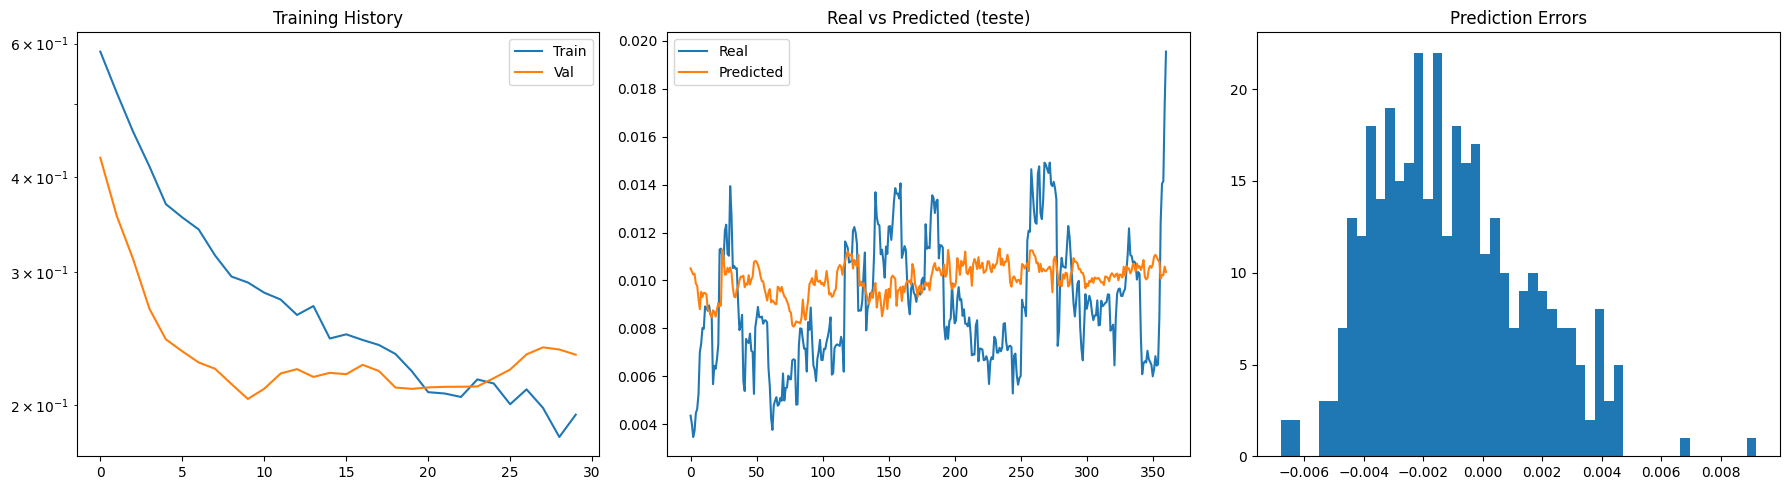


── Correlações com o target (novo) ──
hist_vol_5                0.782225
rv_5                      0.782225
hist_vol_10               0.707049
hist_vol_20               0.647845
rv_20                     0.647845
hist_vol_60               0.532272
rv_60                     0.532272
vix                       0.471686
rv_20_rank                0.459466
rv20_rank_252             0.459466
garch_rank                0.443314
garch_rank_252            0.443314
gvz_zscore_60d            0.348395
oil_market_balance_mbd    0.290269
gvz_pct_change            0.261537
Name: target, dtype: float64


In [219]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(history.history["loss"],     label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_yscale("log")
axes[0].set_title("Training History")
axes[0].legend()
 
axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted (teste)")
axes[1].legend()
 
errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")
 
plt.tight_layout()
plt.show()
 
print("\n── Correlações com o target (novo) ──")
corr_df = pd.DataFrame(X.values, columns=X.columns)
corr_df["target"] = y.values[:len(corr_df)]
correlations = corr_df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
print(correlations.head(15))

In [220]:
eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test,            y_pred_slide_test,  "LSTM TEST  (slide)")


── LSTM TRAIN (slide) ──
  QLIKE    : 0.046328  (baseline média: 0.086123)
  R²       : 0.4547
  Spearman : 0.6137
  std ratio: 0.482  (ideal=1.0)

── LSTM TEST  (slide) ──
  QLIKE    : 0.056267  (baseline média: 0.041931)
  R²       : -0.4941
  Spearman : 0.1660
  std ratio: 0.371  (ideal=1.0)


In [221]:
print(pd.Series(y).autocorr(1))
print(pd.Series(y).autocorr(5))
print(pd.Series(y).autocorr(20))

0.9418173210780398
0.7070229478320387
0.3191396687192726


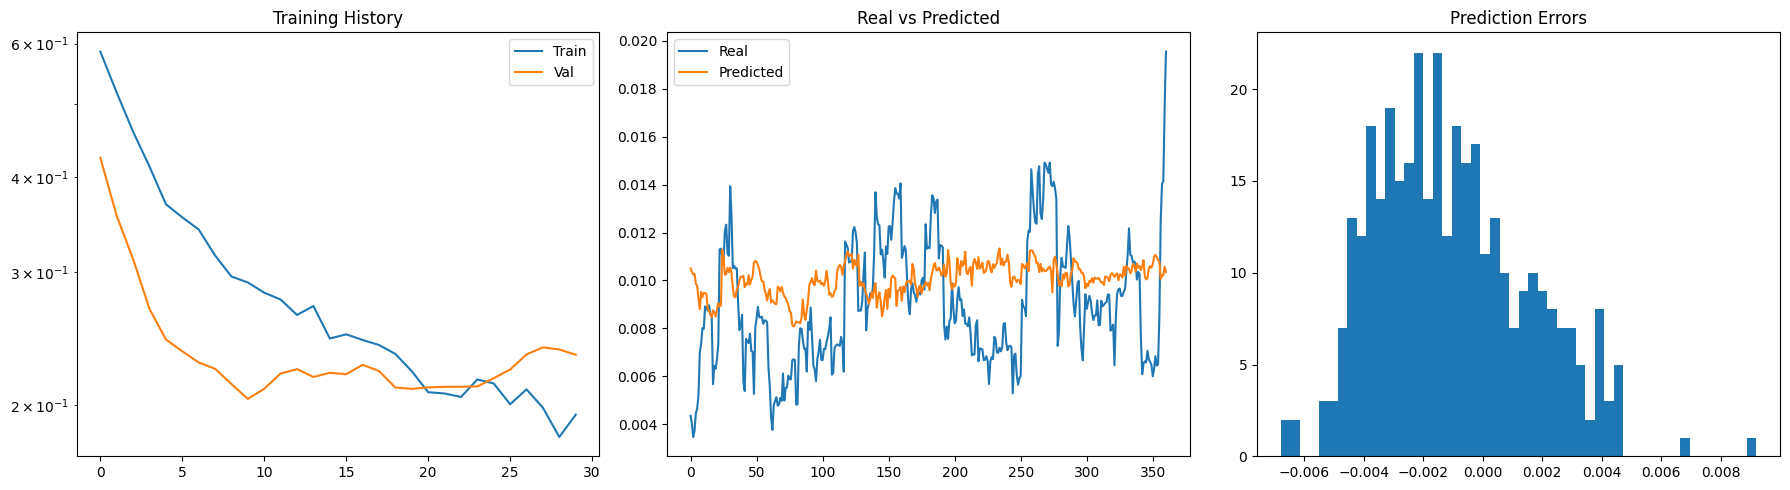

In [222]:
# Célula 12 — Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_yscale('log')
axes[0].set_title("Training History")
axes[0].legend()

axes[1].plot(y_test,                label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted")
axes[1].legend()

errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

In [223]:
eval_metrics(y_slide[:val_cut], y_pred_slide_train, "LSTM TRAIN (slide)")
eval_metrics(y_test_eval,       y_pred_slide_test,  "LSTM TEST  (slide)")


── LSTM TRAIN (slide) ──
  QLIKE    : 0.046328  (baseline média: 0.086123)
  R²       : 0.4547
  Spearman : 0.6137
  std ratio: 0.482  (ideal=1.0)

── LSTM TEST  (slide) ──
  QLIKE    : 0.056267  (baseline média: 0.041931)
  R²       : -0.4941
  Spearman : 0.1660
  std ratio: 0.371  (ideal=1.0)


In [224]:
# Célula 13 — Diagnóstico de correlações
corr = pd.DataFrame(X.values, columns=X.columns)
corr["target"] = y.values[:len(corr)]
correlations = corr.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
correlations

hist_vol_5                           0.782225
rv_5                                 0.782225
hist_vol_10                          0.707049
hist_vol_20                          0.647845
rv_20                                0.647845
hist_vol_60                          0.532272
rv_60                                0.532272
vix                                  0.471686
rv_20_rank                           0.459466
rv20_rank_252                        0.459466
garch_rank                           0.443314
garch_rank_252                       0.443314
gvz_zscore_60d                       0.348395
oil_market_balance_mbd               0.290269
gvz_pct_change                       0.261537
eur_usd                              0.257669
vix_rank_252                         0.250128
vix_rank                             0.250128
usd_rub                             -0.219306
silver_high                          0.203644
petrodolar_brent                     0.203498
platinum_high                     

In [225]:
print("Período completo:", gold["timestamp"].min(), "→", gold["timestamp"].max())
print("Linhas total:", len(gold))
print("\nÚltimas datas do treino (aprox):")
print("Treino vai até ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])
print("Teste começa em ~", gold["timestamp"].iloc[int(len(gold) * 0.9)])

Período completo: 2010-09-08 00:00:00 → 2025-04-03 00:00:00
Linhas total: 3662

Últimas datas do treino (aprox):
Treino vai até ~ 2023-10-17 00:00:00
Teste começa em ~ 2023-10-17 00:00:00


In [226]:
y_train_full.std(), y_test.std()

(np.float64(0.004314333582127048), np.float64(0.0026033636166382045))

In [227]:
df = pd.DataFrame({
    "Return": y_train_full.flatten()
})
df["Return"].autocorr(lag=1)

np.float64(0.9432283640350565)

In [228]:
df["Return"].autocorr(lag=5)

np.float64(0.7112335096535888)

In [229]:
df["Return"].autocorr(lag=10)

np.float64(0.4233749958309398)

In [230]:
df["Return"].autocorr(lag=20)

np.float64(0.32656871828315415)

In [231]:
y.describe()

count    3662.000000
mean        0.009213
std         0.004165
min         0.002123
25%         0.006596
50%         0.008321
75%         0.010792
max         0.037342
Name: target_vol_5d, dtype: float64

In [232]:
print(y.std())

0.004164611928937185


In [233]:
print("Pred treino std:", y_pred_train.std())
print("Pred teste std:", y_pred_test.std())

print("Real treino std:", y_train_full.std())
print("Real teste std:", y_test.std())

Pred treino std: 0.0022620636
Pred teste std: 0.0006697851
Real treino std: 0.004314333582127048
Real teste std: 0.0026033636166382045


In [234]:
correlations

hist_vol_5                           0.782225
rv_5                                 0.782225
hist_vol_10                          0.707049
hist_vol_20                          0.647845
rv_20                                0.647845
hist_vol_60                          0.532272
rv_60                                0.532272
vix                                  0.471686
rv_20_rank                           0.459466
rv20_rank_252                        0.459466
garch_rank                           0.443314
garch_rank_252                       0.443314
gvz_zscore_60d                       0.348395
oil_market_balance_mbd               0.290269
gvz_pct_change                       0.261537
eur_usd                              0.257669
vix_rank_252                         0.250128
vix_rank                             0.250128
usd_rub                             -0.219306
silver_high                          0.203644
petrodolar_brent                     0.203498
platinum_high                     

In [235]:
for col in externos.columns:
    if col != "timestamp":
        first_valid = externos[col].first_valid_index()

        if first_valid is not None:
            print(
                col,
                externos.loc[first_valid, "timestamp"]
            )

dxy 2008-01-02 00:00:00
vix 2008-01-02 00:00:00
oil 2008-01-02 00:00:00
tips 2008-01-02 00:00:00
sp500 2008-01-02 00:00:00
tnx 2008-01-02 00:00:00
gvz 2008-06-03 00:00:00


In [236]:
print("y_train")
print(y_tr.mean(), y_tr.std())

print("\ny_pred")
print(pred.mean(), pred.std())

y_train
0.009313259476491262 0.0043937508746409205

y_pred
0.008375592 0.001578914


In [237]:
from arch import arch_model
log_ret = gold["log_return"].dropna() * 100  
garch = arch_model(log_ret, vol="Garch", p=1, q=1)
res = garch.fit(disp="off")
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5035.92
Distribution:                  Normal   AIC:                           10079.8
Method:            Maximum Likelihood   BIC:                           10104.7
                                        No. Observations:                 3662
Date:                sex, jun 12 2026   Df Residuals:                     3661
Time:                        21:06:37   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0194  1.547e-02      1.252      0.211 

In [238]:
log_ret = gold["log_return"].dropna() * 100

n_test = int(len(log_ret) * TEST_RATIO)
train_ret = log_ret.iloc[:-n_test]
test_ret  = log_ret.iloc[-n_test:]

preds = []
for i in range(len(test_ret)):
    window = log_ret.iloc[:len(train_ret) + i]
    m = arch_model(window, vol="Garch", p=1, q=1)
    r = m.fit(disp="off", show_warning=False)
    f = r.forecast(horizon=1)
    preds.append(np.sqrt(f.variance.values[-1, 0]) / 100)

realized = test_ret.values / 100
realized_vol = pd.Series(realized).rolling(5).std().shift(-5).dropna().values
preds_aligned = np.array(preds[:len(realized_vol)])

print("GARCH R² no teste:", r2_score(realized_vol, preds_aligned))

GARCH R² no teste: 0.008903888512843738


In [239]:
print("Autocorr y lag1 :", pd.Series(y).autocorr(1))
print("Autocorr y lag5 :", pd.Series(y).autocorr(5))
print("Autocorr y lag10:", pd.Series(y).autocorr(10))
print("Autocorr y lag20:", pd.Series(y).autocorr(20))

Autocorr y lag1 : 0.9418173210780398
Autocorr y lag5 : 0.7070229478320387
Autocorr y lag10: 0.4173436214938561
Autocorr y lag20: 0.3191396687192726
